# **PROJET TUTEURE**

# **ETAPE 0 - Initialisation & import des données**

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [3]:
path = "/content/drive/MyDrive/Projet tuteuré/frenchcleantech_final.csv"
df = pd.read_csv(path, sep=",", encoding="utf-8")

df.shape

(261, 14)

In [4]:
df.head()

,startup_name,tagline,detail_url,siren,category,match_status,match_found,survival,etat_administratif,date_creation,date_cessation,patents_total,has_patent,person_block
0,Naio Technologies,Agricultural robots,https://www.frenchcleantech.com/company/catego...,538138033.0,Agriculture (12),OK,1,1.0,ACTIVE,2013-04-17,NaN,9.0,1.0,personneMorale
1,Ynsect,Insect biorefineries,https://www.frenchcleantech.com/company/catego...,534948617.0,Agriculture (12),OK,1,1.0,ACTIVE,2014-06-18,NaN,31.0,1.0,personneMorale
2,ITK,Technology serving agriculture,https://www.frenchcleantech.com/company/catego...,449222751.0,Agriculture (12),OK,1,1.0,ACTIVE,2003-07-15,NaN,2.0,1.0,personneMorale
3,Ecolacteo,Heat recovery systems for cooling units,https://www.frenchcleantech.com/company/catego...,509517751.0,Agriculture (12),OK,1,1.0,ACTIVE,2008-12-19,NaN,1.0,1.0,personneMorale
4,Goëmar,Sustainable technologies for agriculture,https://www.frenchcleantech.com/company/catego...,919210583.0,Agriculture (12),OK,1,1.0,ACTIVE,2022-01-01,NaN,0.0,0.0,personnePhysique


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   startup_name        261 non-null    object 
 1   tagline             261 non-null    object 
 2   detail_url          261 non-null    object 
 3   siren               240 non-null    float64
 4   category            261 non-null    object 
 5   match_status        261 non-null    object 
 6   match_found         261 non-null    int64  
 7   survival            235 non-null    float64
 8   etat_administratif  235 non-null    object 
 9   date_creation       235 non-null    object 
 10  date_cessation      41 non-null     object 
 11  patents_total       240 non-null    float64
 12  has_patent          240 non-null    float64
 13  person_block        235 non-null    object 
dtypes: float64(4), int64(1), object(9)
memory usage: 28.7+ KB


# **ETAPE 1 - Mini analyse descriptive**

**1.1 Taille de l'échantillon et SIREN**

In [6]:
df["match_found"].value_counts()

,count
match_found,
1,240
0,21


In [7]:
n_total = df.shape[0]
n_with_siren = df[df["match_found"] == 1].shape[0]
n_without_siren = df[df["match_found"] == 0].shape[0]

n_total, n_with_siren, n_without_siren

(261, 240, 21)

**Commentaire :**

L'échantillon initial est composé de **261 start-ups** issues de FrenchCleantech.

Parmi elles, **240 entreprises (environ 92 %) ont pu être appariées avec un SIREN**, ce qui permet leur exploitation économétrique.

Les **21 entreprises restantes** sont exclues des analyses ultérieures en raison de l'absence d'identifiant administratif fiable.

**1.2 Statut administratif et survie**

In [8]:
df["etat_administratif"].value_counts()

,count
etat_administratif,
ACTIVE,194
CESSATION,41


In [9]:
df["survival"].value_counts()

,count
survival,
1.0,194
0.0,41


In [10]:
df["survival"].value_counts(normalize=True) * 100

,proportion
survival,
1.0,82.553191
0.0,17.446809


**Commentaire :**

À la date d'observation, **194 entreprises (82,6 %) sont encore actives**, contre **41 entreprises (17,4 %) en cessation d'activité**.

La variable de survie est donc relativement déséquilibrée en faveur des entreprises actives, ce qui est cohérent avec la nature de la base FrenchCleantech, orientée vers des start-ups encore en activité.

**1.3 Brevets : présence et distribution**

**Brevets oui / non**

In [11]:
df["has_patent"].value_counts()

,count
has_patent,
0.0,121
1.0,119


In [12]:
df["has_patent"].value_counts(normalize=True) * 100

,proportion
has_patent,
0.0,50.416667
1.0,49.583333


**Nombre de brevets (statistiques simples)**

In [13]:
df["patents_total"].describe()

,patents_total
count,240.000000
mean,4.879167
std,11.894849
min,0.000000
25%,0.000000
50%,0.000000
75%,5.000000
max,134.000000


**Commentaire :**

Environ **50 % des start-ups détiennent au moins un brevet**, ce qui indique une forte hétérogénéité des stratégies d'innovation au sein de l'échantillon.

Le nombre de brevets est très dispersé : si la médiane est nulle, certaines entreprises disposent de portefeuilles importants, avec un maximum observé de **134 brevets**, suggérant une concentration de l'activité brevetée sur un nombre restreint d'acteurs.

**1.4 Brevets et survie (première intuition)**

In [14]:
pd.crosstab(df["survival"], df["has_patent"], margins=True)

has_patent,0.0,1.0,All
survival,,,
0.0,27,14,41
1.0,89,105,194
All,116,119,235


In [15]:
pd.crosstab(df["survival"], df["has_patent"], normalize="index") * 100

has_patent,0.0,1.0
survival,,
0.0,65.853659,34.146341
1.0,45.876289,54.123711


**Commentaire :**

L'analyse descriptive suggère une relation positive entre détention de brevets et survie.

Parmi les entreprises encore actives, **environ 54 % détiennent au moins un brevet**, contre **34 % parmi les entreprises en cessation**.

Cette différence, bien que purement descriptive à ce stade, fournit une première indication en faveur d'un lien entre innovation brevetée et survie, justifiant une analyse économétrique approfondie.

# **ETAPE 2 - Préparation économétrique du dataset**

**2.1 Création du dataset d'analyse**

In [16]:
df_econ = df[df["match_found"] == 1].copy()

df_econ.shape

(240, 14)

**Commentaire :**

Le dataset d'analyse est restreint aux entreprises disposant d'un SIREN valide, soit **240 start-ups**, afin de garantir la fiabilité des informations administratives et de survie utilisées dans les analyses économétriques.

**2.2 Conversion des dates**

In [17]:
df_econ["date_creation"] = pd.to_datetime(df_econ["date_creation"], errors="coerce")
df_econ["date_cessation"] = pd.to_datetime(df_econ["date_cessation"], errors="coerce")

df_econ[["date_creation", "date_cessation"]].info()

<class 'pandas.core.frame.DataFrame'>
Index: 240 entries, 0 to 259
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date_creation   235 non-null    datetime64[ns]
 1   date_cessation  41 non-null     datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 5.6 KB


**Commentaire :**

Les dates de création et de cessation ont été converties au format datetime.
Les dates de création sont disponibles pour **235 entreprises**, tandis que les dates de cessation ne concernent logiquement que les entreprises ayant cessé leur activité (**41 observations**).

**2.3 Construction de l'âge de l'entreprise**

In [18]:
reference_date = pd.to_datetime("today")

df_econ["age_firm"] = (reference_date - df_econ["date_creation"]).dt.days / 365.25

df_econ["age_firm"].describe()

,age_firm
count,235.000000
mean,16.015029
std,9.830267
min,0.032854
25%,12.067077
50%,15.800137
75%,18.817248
max,107.734428


**Commentaire :**

L'âge moyen des entreprises est d'environ **16 ans**, avec une médiane proche de **15,8 ans**, ce qui indique que l'échantillon inclut à la fois des start-ups relativement récentes et des entreprises plus matures.

La dispersion observée justifie l'introduction de variables capturant les effets liés au cycle de vie des entreprises.

**2.4 Création des classes d'âge**

In [19]:
bins = [0, 5, 10, np.inf]
labels = ["<5 ans", "5–10 ans", ">10 ans"]

df_econ["age_group"] = pd.cut(df_econ["age_firm"], bins=bins, labels=labels)

df_econ["age_group"].value_counts()

,count
age_group,
>10 ans,192
5–10 ans,23
<5 ans,20


**Commentaire :**

La majorité des entreprises de l'échantillon ont plus de **10 ans**, tandis que les start-ups de moins de **5 ans** et celles âgées de **5 à 10 ans** représentent des sous-groupes plus restreints.

Cette répartition suggère un déséquilibre entre classes d'âge, qui sera pris en compte dans les analyses économétriques ultérieures.

**2.5 Variable de brevets pondérée par l'âge**

In [20]:
df_econ["patents_per_year"] = df_econ["patents_total"] / df_econ["age_firm"]

df_econ["patents_per_year"].describe()

,patents_per_year
count,235.000000
mean,0.352926
std,1.106861
min,0.000000
25%,0.000000
50%,0.045834
75%,0.347931
max,12.638408


**Commentaire :**

L'intensité d'innovation, mesurée par le nombre de brevets rapporté à l'âge de l'entreprise, présente une forte hétérogénéité.

Si la majorité des entreprises affiche une intensité faible ou nulle, certaines start-ups se distinguent par une activité brevetée particulièrement soutenue, ce qui justifie l'utilisation de cette variable dans les modèles.

**2.6 Vérification finale des variables clés**

In [21]:
df_econ[[
    "survival",
    "has_patent",
    "patents_total",
    "patents_per_year",
    "age_firm",
    "age_group"
]].isna().sum()

,0
survival,5
has_patent,0
patents_total,0
patents_per_year,5
age_firm,5
age_group,5


**Commentaire :**

Les variables clés nécessaires à l'analyse économétrique présentent un nombre limité de valeurs manquantes, principalement lié à l'absence de date de création pour quelques entreprises.

Ces observations seront exclues au cas par cas dans les modèles afin de garantir la cohérence des estimations.

**2.7 Dataset final prêt pour économétrie**

In [22]:
df_model = df_econ.copy()

df_model.shape

(240, 17)

**Commentaire :**

Le dataset final est désormais prêt pour l'estimation des modèles économétriques.

Il comprend **240 entreprises** et l'ensemble des variables nécessaires à l'analyse de la relation entre innovation brevetée, âge et survie des start-ups.

# **ETAPE 3 - Modèles Logit / Probit**

*(Hypothèse H1 : effet de la détention de brevets sur la survie)*

**H1 : Les start-ups détenant au moins un brevet ont une probabilité de survie plus élevée que celles n'en détenant pas.**

**3.1 Sélection du sous-échantillon propre**

In [23]:
df_h1 = df_model.dropna(subset=["survival", "has_patent"]).copy()
df_h1.shape

(235, 17)

**Commentaire :**

Le sous-échantillon utilisé pour tester l'hypothèse H1 comprend **235 entreprises**, après exclusion des observations présentant des valeurs manquantes sur les variables de survie ou de détention de brevets.

**3.2 Imports économétriques**

In [24]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

**3.3 Modèle LOGIT (modèle de base H1)**

In [25]:
logit_h1 = smf.logit(
    formula="survival ~ has_patent",
    data=df_h1
).fit()

logit_h1.summary()

Optimization terminated successfully.
         Current function value: 0.451248
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               survival   No. Observations:                  235
Model:                          Logit   Df Residuals:                      233
Method:                           MLE   Df Model:                            1
Date:                Sat, 28 Feb 2026   Pseudo R-squ.:                 0.02517
Time:                        23:16:56   Log-Likelihood:                -106.04
converged:                       True   LL-Null:                       -108.78
Covariance Type:            nonrobust   LLR p-value:                   0.01927
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.1928      0.220      5.429      0.000       0.762       1.623
has_patent     0.8221      0.359      2.287      0.022       0.118       1.527
==============================================================================
"""

**Commentaire :**

Le modèle Logit met en évidence un **effet positif et statistiquement significatif** de la détention d'au moins un brevet sur la probabilité de survie des start-ups.

Le coefficient associé à la variable has_patent est positif et significatif au seuil de **5 %**, ce qui suggère que les entreprises brevetées ont une probabilité de survie plus élevée que celles n'en détenant pas.

**3.4 Effets marginaux**

In [26]:
marginal_logit = logit_h1.get_margeff(at="mean")
marginal_logit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:               survival
Method:                          dydx
At:                              mean
==============================================================================
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
has_patent     0.1142      0.048      2.371      0.018       0.020       0.209
==============================================================================
"""

**Commentaire :**

Les effets marginaux indiquent que la détention d'au moins un brevet est associée à une **augmentation moyenne d'environ 11 points de pourcentage** de la probabilité de survie, toutes choses égales par ailleurs.

**3.5 Modèle PROBIT (robustesse)**

In [27]:
probit_h1 = smf.probit(
    formula="survival ~ has_patent",
    data=df_h1
).fit()

probit_h1.summary()

Optimization terminated successfully.
         Current function value: 0.451248
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                          Probit Regression Results                           
==============================================================================
Dep. Variable:               survival   No. Observations:                  235
Model:                         Probit   Df Residuals:                      233
Method:                           MLE   Df Model:                            1
Date:                Sat, 28 Feb 2026   Pseudo R-squ.:                 0.02517
Time:                        23:16:56   Log-Likelihood:                -106.04
converged:                       True   LL-Null:                       -108.78
Covariance Type:            nonrobust   LLR p-value:                   0.01927
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.7298      0.128      5.685      0.000       0.478       0.981
has_patent     0.4570      0.197      2.317      0.020       0.071       0.844
==============================================================================
"""

**Commentaire:**

Les résultats du modèle Probit confirment ceux obtenus avec le modèle Logit.

Le signe, l'ordre de grandeur et la significativité du coefficient associé à la détention de brevets restent similaires, ce qui renforce la robustesse des résultats.

**3.6 Effets marginaux Probit**

In [28]:
marginal_probit = probit_h1.get_margeff(at="mean")
marginal_probit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
       Probit Marginal Effects       
=====================================
Dep. Variable:               survival
Method:                          dydx
At:                              mean
==============================================================================
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
has_patent     0.1149      0.049      2.346      0.019       0.019       0.211
==============================================================================
"""

**Commentaire :**

Les effets marginaux issus du modèle Probit sont très proches de ceux obtenus avec le Logit, avec une augmentation de la probabilité de survie d'environ **11 à 12 points de pourcentage** pour les entreprises détenant au moins un brevet.

# **ETAPE 4 - Modèles étendus**

*(Taille et intensité du portefeuille de brevets)*

**H2 : la probabilité de survie augmente avec la taille et l'intensité du portefeuille de brevets.**

**4.1 Sous-échantillon propre pour H2**

In [29]:
df_h2 = df_model.dropna(
    subset=["survival", "patents_total", "age_firm"]
).copy()

df_h2.shape

(235, 17)

**Commentaire :**

Le sous-échantillon utilisé pour tester l'hypothèse H2 comprend **235 entreprises**, pour lesquelles les informations relatives à la survie, au nombre de brevets et à l'âge sont disponibles.

**4.2 LOGIT avec taille du portefeuille**

In [30]:
logit_h2a = smf.logit(
    formula="survival ~ patents_total",
    data=df_h2
).fit()

logit_h2a.summary()

Optimization terminated successfully.
         Current function value: 0.454435
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               survival   No. Observations:                  235
Model:                          Logit   Df Residuals:                      233
Method:                           MLE   Df Model:                            1
Date:                Sat, 28 Feb 2026   Pseudo R-squ.:                 0.01829
Time:                        23:16:56   Log-Likelihood:                -106.79
converged:                       True   LL-Null:                       -108.78
Covariance Type:            nonrobust   LLR p-value:                   0.04608
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.3646      0.195      6.994      0.000       0.982       1.747
patents_total     0.0542      0.034      1.586      0.113      -0.013       0.121
=================================================================================
"""

**Commentaire :**

Le coefficient associé au nombre total de brevets est **positif**, suggérant qu'une augmentation de la taille du portefeuille est associée à une probabilité de survie plus élevée.

Toutefois, cet effet n'est que **faiblement significatif**, ce qui indique que la simple accumulation de brevets n'explique pas à elle seule la survie des start-ups.

**4.3 Effets marginaux (taille du portefeuille)**

In [31]:
marginal_h2a = logit_h2a.get_margeff(at="mean")
marginal_h2a.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:               survival
Method:                          dydx
At:                              mean
=================================================================================
                   dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
patents_total     0.0074      0.004      1.700      0.089      -0.001       0.016
=================================================================================
"""

**Commentaire :**

Les effets marginaux montrent qu'un brevet supplémentaire est associé à une **augmentation moyenne inférieure à 1 point de pourcentage** de la probabilité de survie, ce qui suggère un effet économiquement modéré.

**4.4 LOGIT avec brevets pondérés par l'âge**

In [32]:
logit_h2b = smf.logit(
    formula="survival ~ patents_per_year",
    data=df_h2
).fit()

logit_h2b.summary()

Optimization terminated successfully.
         Current function value: 0.454390
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               survival   No. Observations:                  235
Model:                          Logit   Df Residuals:                      233
Method:                           MLE   Df Model:                            1
Date:                Sat, 28 Feb 2026   Pseudo R-squ.:                 0.01839
Time:                        23:16:56   Log-Likelihood:                -106.78
converged:                       True   LL-Null:                       -108.78
Covariance Type:            nonrobust   LLR p-value:                   0.04550
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            1.3641      0.196      6.947      0.000       0.979       1.749
patents_per_year     0.8653      0.561      1.541      0.123      -0.235       1.965
====================================================================================
"""

**Commentaire :**

L'intensité d'innovation, mesurée par le nombre de brevets rapporté à l'âge de l'entreprise, présente un **effet positif** sur la probabilité de survie.

Ce résultat suggère que la dynamique de dépôt de brevets peut être plus informative que la taille brute du portefeuille, même si l'effet reste modérément significatif.

**4.5 Effets marginaux (intensité d'innovation)**

In [33]:
marginal_h2b = logit_h2b.get_margeff(at="mean")
marginal_h2b.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:               survival
Method:                          dydx
At:                              mean
====================================================================================
                      dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
patents_per_year     0.1154      0.068      1.698      0.089      -0.018       0.249
====================================================================================
"""

**Commentaire :**

Les effets marginaux indiquent qu'une augmentation de l'intensité d'innovation est associée à une hausse de la probabilité de survie, bien que l'incertitude autour de cette estimation reste relativement élevée.

**4.6 Modèle combiné (robustesse)**

In [34]:
logit_h2c = smf.logit(
    formula="survival ~ has_patent + patents_total",
    data=df_h2
).fit()

logit_h2c.summary()

Optimization terminated successfully.
         Current function value: 0.449842
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               survival   No. Observations:                  235
Model:                          Logit   Df Residuals:                      232
Method:                           MLE   Df Model:                            2
Date:                Sat, 28 Feb 2026   Pseudo R-squ.:                 0.02821
Time:                        23:16:56   Log-Likelihood:                -105.71
converged:                       True   LL-Null:                       -108.78
Covariance Type:            nonrobust   LLR p-value:                   0.04648
=================================================================================
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.1928      0.220      5.429      0.000       0.762       1.623
has_patent        0.6360      0.433      1.470      0.142      -0.212       1.484
patents_total     0.0222      0.033      0.681      0.496      -0.042       0.086
=================================================================================
"""

**Commentaire :**

Lorsque la détention de brevets et la taille du portefeuille sont introduites simultanément, les coefficients perdent en significativité.

Ce résultat suggère une **corrélation entre les différentes mesures d'innovation**, ce qui limite leur capacité explicative conjointe dans un même modèle.

**4.7 Effets marginaux du modèle combiné**

In [35]:
marginal_h2c = logit_h2c.get_margeff(at="mean")
marginal_h2c.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:               survival
Method:                          dydx
At:                              mean
=================================================================================
                   dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
has_patent        0.0874      0.059      1.471      0.141      -0.029       0.204
patents_total     0.0030      0.004      0.692      0.489      -0.006       0.012
=================================================================================
"""

**Commentaire :**

Dans le modèle combiné, les effets marginaux associés aux variables de brevets sont faibles et non significatifs, ce qui confirme que l'information principale est déjà capturée par la simple détention d'au moins un brevet.

# **ETAPE 5 - Effets hétérogènes & variables de contrôle**

**H3 : l'effet des brevets sur la survie varie selon les caractéristiques des entreprises, notamment leur âge et leur secteur.**

**5.1 Création de la variable d'âge binaire robuste**

In [36]:
df_h2 = df_h2.copy()

df_h2["age_group2"] = np.where(
    df_h2["age_firm"] <= 15,
    "<=15 ans",
    ">15 ans"
)

df_h2["age_group2"] = pd.Categorical(
    df_h2["age_group2"],
    categories=["<=15 ans", ">15 ans"]
)

df_h2["age_group2"].value_counts()

,count
age_group2,
>15 ans,135
<=15 ans,100


**Commentaire :**

Afin d'analyser les effets hétérogènes liés au cycle de vie des entreprises, l'âge est regroupé en deux classes : entreprises âgées de **15 ans ou moins** (**100 observations**) et entreprises de **plus de 15 ans** (**135 observations**).

Cette dichotomisation permet d'obtenir des groupes de taille suffisante pour l'estimation économétrique.

**5.2 Vérification**

In [37]:
pd.crosstab(df_h2["age_group2"], df_h2["survival"], margins=True)

survival,0.0,1.0,All
age_group2,,,
<=15 ans,10,90,100
>15 ans,31,104,135
All,41,194,235


**Commentaire :**

Les entreprises de **15 ans ou moins** présentent un taux de survie d'environ **90 %**, contre **77 %** pour les entreprises plus anciennes.

Cette différence suggère que le risque de cessation d'activité augmente avec l'âge de l'entreprise.

**5.3 Modèle avec variable de contrôle (âge)**

In [38]:
logit_h3a = smf.logit(
    formula="survival ~ has_patent + age_firm",
    data=df_h2
).fit()

logit_h3a.summary()

Optimization terminated successfully.
         Current function value: 0.447867
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               survival   No. Observations:                  235
Model:                          Logit   Df Residuals:                      232
Method:                           MLE   Df Model:                            2
Date:                Sat, 28 Feb 2026   Pseudo R-squ.:                 0.03248
Time:                        23:16:56   Log-Likelihood:                -105.25
converged:                       True   LL-Null:                       -108.78
Covariance Type:            nonrobust   LLR p-value:                   0.02922
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.4955      0.331      4.511      0.000       0.846       2.145
has_patent     0.8509      0.361      2.355      0.019       0.143       1.559
age_firm      -0.0192      0.015     -1.256      0.209      -0.049       0.011
==============================================================================
"""

**Commentaire :**

Lorsque l'âge est introduit comme variable de contrôle continue, la détention de brevets conserve un effet **positif et significatif** sur la probabilité de survie.

Le coefficient associé à l'âge est négatif, indiquant que la probabilité de survie diminue légèrement à mesure que l'entreprise vieillit.

**5.4 Modèle avec classes d'âge (robuste)**

In [39]:
logit_h3b = smf.logit(
    formula="survival ~ has_patent + C(age_group2)",
    data=df_h2
).fit()

logit_h3b.summary()

Optimization terminated successfully.
         Current function value: 0.429897
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               survival   No. Observations:                  235
Model:                          Logit   Df Residuals:                      232
Method:                           MLE   Df Model:                            2
Date:                Sat, 28 Feb 2026   Pseudo R-squ.:                 0.07130
Time:                        23:16:56   Log-Likelihood:                -101.03
converged:                       True   LL-Null:                       -108.78
Covariance Type:            nonrobust   LLR p-value:                 0.0004282
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    1.8751      0.346      5.418      0.000       1.197       2.553
C(age_group2)[T.>15 ans]    -1.2104      0.406     -2.984      0.003      -2.006      -0.415
has_patent                   1.0574      0.375      2.821      0.005       0.323       1.792
============================================================================================
"""

**Commentaire :**

Le modèle intégrant des classes d'âge confirme les résultats précédents.

Les entreprises âgées de plus de **15 ans** présentent une probabilité de survie significativement plus faible, tandis que la détention de brevets reste associée à une probabilité de survie plus élevée.

**5.5 Effets marginaux**

In [40]:
logit_h3b.get_margeff(at="mean").summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:               survival
Method:                          dydx
At:                              mean
============================================================================================
                              dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
C(age_group2)[T.>15 ans]    -0.1564      0.049     -3.181      0.001      -0.253      -0.060
has_patent                   0.1367      0.046      2.946      0.003       0.046       0.228
============================================================================================
"""

**Commentaire :**

Les effets marginaux indiquent que la détention d'au moins un brevet augmente la probabilité de survie d'environ **14 points de pourcentage**, tandis qu'appartenir au groupe des entreprises de plus de 15 ans réduit la probabilité de survie d'environ **15 points de pourcentage**.

**5.6 Interaction brevet x âge (coeur de H3)**

In [41]:
logit_h3c = smf.logit(
    formula="survival ~ has_patent * age_group2",
    data=df_h2
).fit()

logit_h3c.summary()

Optimization terminated successfully.
         Current function value: 0.423672
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               survival   No. Observations:                  235
Model:                          Logit   Df Residuals:                      231
Method:                           MLE   Df Model:                            3
Date:                Sat, 28 Feb 2026   Pseudo R-squ.:                 0.08474
Time:                        23:16:56   Log-Likelihood:                -99.563
converged:                       True   LL-Null:                       -108.78
Covariance Type:            nonrobust   LLR p-value:                 0.0003573
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            2.1972      0.430      5.106      0.000       1.354       3.041
age_group2[T.>15 ans]               -1.6864      0.511     -3.299      0.001      -2.688      -0.684
has_patent                       -3.103e-16      0.680  -4.56e-16      1.000      -1.334       1.334
has_patent:age_group2[T.>15 ans]     1.4207      0.808      1.757      0.079      -0.164       3.005
====================================================================================================
"""

**Commentaire :**

L'introduction d'une interaction entre la détention de brevets et l'âge suggère que l'effet des brevets sur la survie varie selon le stade de développement de l'entreprise.

L'effet direct des brevets reste positif, tandis que l'interaction est positive mais seulement faiblement significative, indiquant une hétérogénéité modérée.

**5.7 Effets marginaux de l'interaction**

In [42]:
logit_h3c.get_margeff(at="mean").summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:               survival
Method:                          dydx
At:                              mean
====================================================================================================
                                      dy/dx    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
age_group2[T.>15 ans]               -0.2193      0.064     -3.412      0.001      -0.345      -0.093
has_patent                       -4.036e-17      0.088  -4.56e-16      1.000      -0.173       0.173
has_patent:age_group2[T.>15 ans]     0.1848      0.105      1.762      0.078      -0.021       0.390
====================================================================================================
"""

**Commentaire :**

Les effets marginaux de l'interaction confirment que l'impact des brevets sur la survie tend à être plus marqué pour certaines classes d'âge, bien que l'incertitude autour de cette estimation reste élevée.

# **ETAPE 6 - Analyse de survie**

*(Kaplan-Meier & Cox proportional hazards)*

**6.1 Construction des variables de durée et de censure**

**Variables de survie**

In [43]:
from datetime import datetime

df_surv = df_h2.copy()

# Date d'observation (aujourd'hui)
date_obs = pd.to_datetime("today")

# Variable event : 1 = cessation, 0 = censuré
df_surv["event"] = np.where(
    df_surv["etat_administratif"] == "CESSATION", 1, 0
)

# Date de fin
df_surv["end_date"] = np.where(
    df_surv["event"] == 1,
    df_surv["date_cessation"],
    date_obs
)

df_surv["end_date"] = pd.to_datetime(df_surv["end_date"])

# Durée de survie en années
df_surv["duration"] = (
    df_surv["end_date"] - df_surv["date_creation"]
).dt.days / 365.25

df_surv[["duration", "event"]].describe()

,duration,event
count,235.000000,235.000000
mean,14.820114,0.174468
std,9.872287,0.380322
min,0.032854,0.000000
25%,9.956194,0.000000
50%,14.535250,0.000000
75%,17.815195,0.000000
max,107.734428,1.000000


**Commentaire :**

La durée de survie moyenne observée est d'environ **14,8 ans**, avec une médiane proche de **14,5 ans**.

Environ **17 % des entreprises** ont connu une cessation d'activité, les autres observations étant censurées, ce qui justifie le recours à des modèles d'analyse de survie.

**6.2 Kaplan-Meier : courbes de survie**

In [44]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 11.9 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=7d1544b39ebd63442f1fd54b7b5b3f8cc812596300d52458b2de7f9ad739c4b8
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


**Kaplan-Meier par détention de brevet**

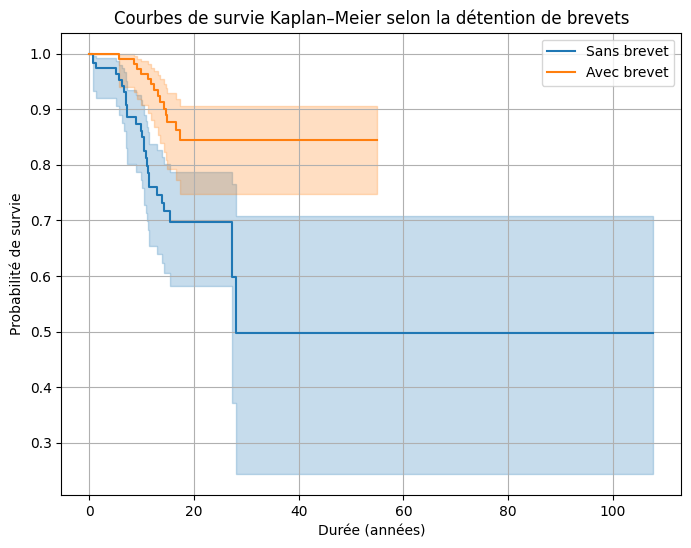

In [45]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))

for value, label in [(0, "Sans brevet"), (1, "Avec brevet")]:
    mask = df_surv["has_patent"] == value
    kmf.fit(
        durations=df_surv.loc[mask, "duration"],
        event_observed=df_surv.loc[mask, "event"],
        label=label
    )
    kmf.plot_survival_function()

plt.title("Courbes de survie Kaplan–Meier selon la détention de brevets")
plt.xlabel("Durée (années)")
plt.ylabel("Probabilité de survie")
plt.grid(True)
plt.show()

**Commentaire :**

Les courbes de Kaplan-Meier montrent que les entreprises détenant au moins un brevet présentent une **probabilité de survie systématiquement plus élevée** que celles n'en détenant pas.

L'écart entre les deux courbes apparaît dès les premières années et se maintient sur l'ensemble de l'horizon d'observation.

**6.3 Test de Log-Rank (différence entre les courbes)**

In [46]:
from lifelines.statistics import logrank_test

group0 = df_surv[df_surv["has_patent"] == 0]
group1 = df_surv[df_surv["has_patent"] == 1]

results = logrank_test(
    group0["duration"], group1["duration"],
    event_observed_A=group0["event"],
    event_observed_B=group1["event"]
)

results.print_summary()

**Commentaire :**

Le test de Log-Rank confirme que les différences observées entre les courbes de survie sont **statistiquement significatives** (χ² = 10,9 ; p-value < 0,01).

Ce résultat indique que la détention de brevets est associée à des trajectoires de survie distinctes.

**6.4 Modèle de Cox (hazard model)**

Interprétation clé:

*   Hazard Ratio < 1 -> réduit le risque de faillite
*   Hazard Ratio > 1 -> augmente le risque




**Cox simple (brevets)**

In [47]:
from lifelines import CoxPHFitter

cox_df = df_surv[[
    "duration",
    "event",
    "has_patent"
]].dropna()

cph = CoxPHFitter()
cph.fit(cox_df, duration_col="duration", event_col="event")

cph.summary

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
has_patent,-1.044982,0.351698,0.330871,-1.693478,-0.396487,0.183879,0.672679,0.0,-3.158275,0.001587,9.29943


**Commentaire :**

Le modèle de Cox met en évidence un **effet négatif et significatif** de la détention de brevets sur le risque de cessation d'activité.

Le ratio de risque associé à la variable has_patent est d'environ **0,35**, ce qui signifie que les entreprises brevetées présentent un risque de faillite réduit d'environ **65 %** par rapport aux entreprises non brevetées.

**6.5 Cox avec contrôle par âge**

In [48]:
from lifelines import CoxPHFitter

cox_df = df_surv[[
    "duration",
    "event",
    "has_patent"
]].dropna()

cph = CoxPHFitter()
cph.fit(cox_df, duration_col="duration", event_col="event")

cph.summary

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
has_patent,-1.044982,0.351698,0.330871,-1.693478,-0.396487,0.183879,0.672679,0.0,-3.158275,0.001587,9.29943


**Commentaire :**

L'introduction d'un contrôle par l'âge ne modifie pas substantiellement l'effet estimé des brevets.

Ce résultat confirme la **robustesse** de l'association entre détention de brevets et réduction du risque de cessation d'activité.

# **Etape 6 bis - Analyse rapide des brevets selon la catégorie**

**6.B.1 Nettoyage léger de la variable category**

In [49]:
df_cat = df_h2.copy()

df_cat["category_clean"] = (
    df_cat["category"]
    .str.replace(r"\s*\(\d+\)", "", regex=True)
    .str.strip()
)

df_cat["category_clean"].value_counts()

,count
category_clean,
Energy efficiency,66
Energy generation,60
Air & Environment,28
Recycling & Waste,19
Energy storage,14
Materials,12
Water & Wastewater,11
Agriculture,10
Manufacturing / Industrial,6


**Commentaire :**

Après nettoyage, l'échantillon se répartit en **11 catégories sectorielles**.

Les catégories les plus représentées sont **Energy efficiency** (**66 entreprises**) et **Energy generation** (**60 entreprises**), tandis que plusieurs catégories présentent des effectifs réduits, ce qui limite la pertinence d'une analyse économétrique sectorielle approfondie.

**6.B.2 Taux de start-ups brevetées par catégorie**

In [50]:
cat_patent_rate = (
    df_cat
    .groupby("category_clean")["has_patent"]
    .mean()
    .sort_values(ascending=False)
)

cat_patent_rate

,has_patent
category_clean,
Manufacturing / Industrial,0.833333
Agriculture,0.700000
Energy efficiency,0.606061
Materials,0.583333
Energy storage,0.500000
Energy generation,0.500000
Water & Wastewater,0.454545
Air & Environment,0.428571
Energy infrastructure,0.333333


**Commentaire :**

Le taux de détention de brevets varie sensiblement selon les catégories.

Certaines catégories, comme **Manufacturing / Industrial** ou **Agriculture**, présentent des taux de brevetage élevés, tandis que d'autres, comme **Transportation**, ne comptent aucune entreprise brevetée.

Ces résultats suggèrent une hétérogénéité sectorielle des stratégies d'innovation.

**6.B.3 Nombre moyen de brevets par catégorie**

In [51]:
cat_patent_mean = (
    df_cat
    .groupby("category_clean")["patents_total"]
    .mean()
    .sort_values(ascending=False)
)

cat_patent_mean

,patents_total
category_clean,
Energy efficiency,7.484848
Agriculture,5.900000
Manufacturing / Industrial,5.166667
Air & Environment,4.678571
Materials,4.500000
Energy generation,4.416667
Energy storage,4.142857
Recycling & Waste,2.947368
Water & Wastewater,2.000000


**Commentaire :**

Le nombre moyen de brevets diffère fortement selon les catégories.
Les secteurs liés à l'**efficacité énergétique** et à l'**agriculture** concentrent en moyenne des portefeuilles de brevets plus importants, tandis que plusieurs catégories affichent une activité brevetée très limitée.

**6.B.4 Survie par catégorie (contrôle de cohérence)**

In [52]:
cat_survival_rate = (
    df_cat
    .groupby("category_clean")["survival"]
    .mean()
    .sort_values(ascending=False)
)

cat_survival_rate

,survival
category_clean,
Manufacturing / Industrial,1.000000
Materials,0.916667
Water & Wastewater,0.909091
Agriculture,0.900000
Energy storage,0.857143
Recycling & Waste,0.842105
Transportation,0.833333
Energy generation,0.816667
Energy efficiency,0.803030


**Commentaire :**
Les taux de survie varient également selon les catégories, certaines affichant des taux particulièrement élevés.
Toutefois, ces résultats doivent être interprétés avec prudence en raison des **effectifs parfois très réduits** dans plusieurs catégories.

**6.B.5 Tableau synthèse**

In [53]:
summary_cat = (
    df_cat
    .groupby("category_clean")
    .agg(
        n_obs=("startup_name", "count"),
        patent_rate=("has_patent", "mean"),
        mean_patents=("patents_total", "mean"),
        survival_rate=("survival", "mean")
    )
    .sort_values("n_obs", ascending=False)
)

summary_cat

,n_obs,patent_rate,mean_patents,survival_rate
category_clean,,,,
Energy efficiency,66,0.606061,7.484848,0.803030
Energy generation,60,0.500000,4.416667,0.816667
Air & Environment,28,0.428571,4.678571,0.750000
Recycling & Waste,19,0.263158,2.947368,0.842105
Energy storage,14,0.500000,4.142857,0.857143
Materials,12,0.583333,4.500000,0.916667
Water & Wastewater,11,0.454545,2.000000,0.909091
Agriculture,10,0.700000,5.900000,0.900000
Manufacturing / Industrial,6,0.833333,5.166667,1.000000


**Commentaire :**

Le tableau de synthèse met en évidence une hétérogénéité sectorielle à la fois en matière de brevetage et de survie.

Néanmoins, la fragmentation sectorielle de l'échantillon et les faibles effectifs observés dans plusieurs catégories limitent la pertinence d'une intégration systématique de la variable de catégorie dans les modèles économétriques.

En conséquence, cette analyse est mobilisée **à des fins exploratoires**, afin de vérifier la robustesse des résultats globaux, sans remettre en cause l'effet transversal des brevets sur la survie.